STEP 1: Downloading dataset
Using Colab cache for faster access to the 'cedardataset' dataset.
Genuine folder: /kaggle/input/cedardataset/signatures/full_org
Forged folder: /kaggle/input/cedardataset/signatures/full_forg
STEP 2: Loading images
Writers: 55
Genuine images: 1320
Forged images: 1320
STEP 3: Splitting writers
STEP 4: Generating pairs
Train pairs: 4864
Validation pairs: 1024
Test pairs: 1152
STEP 5: Building Siamese Network


Model: "siamese_signature_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 155, 220,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 155, 220,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ signature_encoder   │ (None, 128)       │    256,768 │ input_layer_3[0]… │
│ (Functional)        │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 128)       │          0 │ signature_encode… │
│                     │                   │            │ signature_encode… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128)       │          0 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 265,089 (1.01 MB)

 Trainable params: 265,089 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

STEP 6: Training model
Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.6869 - loss: 0.5212 - val_accuracy: 0.6934 - val_loss: 0.4988
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.7087 - loss: 0.4763 - val_accuracy: 0.7002 - val_loss: 0.4814
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.7401 - loss: 0.4578 - val_accuracy: 0.7148 - val_loss: 0.4732
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.7519 - loss: 0.4412 - val_accuracy: 0.7197 - val_loss: 0.4570
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.7710 - loss: 0.4235 - val_accuracy: 0.7324 - val_loss: 0.4378
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - accuracy: 0.7915 - loss: 0.4072 - val_accuracy: 0.7500 - val_loss: 0.4290
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.7936 - loss: 0.3997 - val_accuracy: 0.8027 - val_loss: 0.3834
Epoch 8/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0

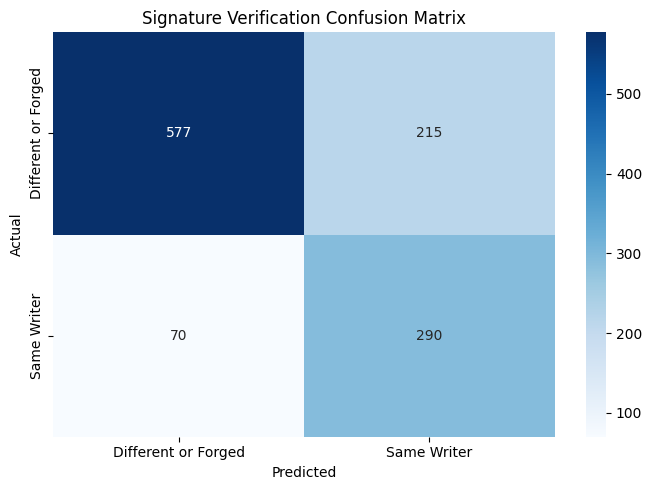

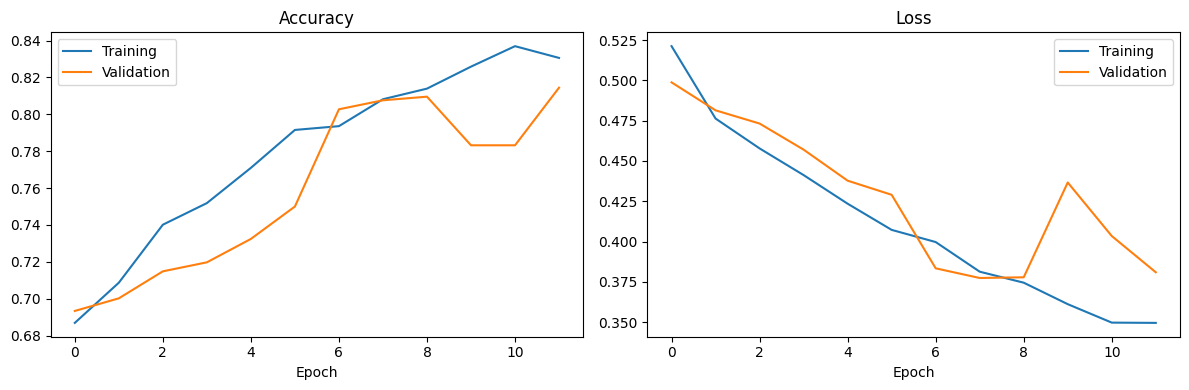

STEP 8: Saving model and results
Model saved successfully.
Results CSV saved successfully.
PROJECT COMPLETED


In [3]:

!pip -q install kagglehub tensorflow scikit-learn seaborn matplotlib pillow pandas

import os
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub
import pandas as pd

from pathlib import Path
from PIL import Image
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (155, 220)
BATCH_SIZE = 32
EPOCHS = 15

print("STEP 1: Downloading dataset")

DATASET_PATH = Path(
    kagglehub.dataset_download("shreelakshmigp/cedardataset")
)

def find_folder(root, name):
    matches = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() == name.lower()
    ]
    if not matches:
        raise FileNotFoundError(
            f"Folder '{name}' not found. Dataset structure: {root}"
        )
    return matches[0]

GENUINE_DIR = find_folder(DATASET_PATH, "full_org")
FORGED_DIR = find_folder(DATASET_PATH, "full_forg")

print("Genuine folder:", GENUINE_DIR)
print("Forged folder:", FORGED_DIR)

def extract_writer_id(path):
    match = re.search(
        r"(?:original|forgeries)[_-](\d+)[_-](\d+)",
        path.stem,
        re.IGNORECASE
    )
    return int(match.group(1)) if match else None

def load_images(folder):
    records = {}
    extensions = {
        ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"
    }

    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in extensions:
            continue

        writer = extract_writer_id(path)
        if writer is None:
            continue

        try:
            with Image.open(path) as im:
                im = im.convert("L").resize(
                    (IMG_SIZE[1], IMG_SIZE[0])
                )
                arr = np.asarray(im, dtype=np.float32) / 255.0
                arr = arr[..., np.newaxis]

            records.setdefault(writer, []).append(arr)

        except Exception:
            continue

    return records

print("STEP 2: Loading images")

genuine_data = load_images(GENUINE_DIR)
forged_data = load_images(FORGED_DIR)

common_writers = sorted(
    set(genuine_data) & set(forged_data)
)

genuine_data = {
    w: genuine_data[w] for w in common_writers
}
forged_data = {
    w: forged_data[w] for w in common_writers
}

print("Writers:", len(common_writers))
print("Genuine images:", sum(len(v) for v in genuine_data.values()))
print("Forged images:", sum(len(v) for v in forged_data.values()))

if len(common_writers) < 5:
    raise ValueError(
        "Writer IDs were not detected correctly. "
        "Check the dataset filenames before training."
    )

print("STEP 3: Splitting writers")

train_writers, remaining_writers = train_test_split(
    np.array(common_writers),
    test_size=0.30,
    random_state=SEED
)

val_writers, test_writers = train_test_split(
    remaining_writers,
    test_size=0.50,
    random_state=SEED
)

def make_pairs(selected_writers, seed):
    rng = random.Random(seed)
    pairs = []
    labels = []

    for writer in selected_writers:
        writer = int(writer)
        originals = genuine_data[writer]
        forgeries = forged_data[writer]

        positive = list(combinations(originals, 2))
        rng.shuffle(positive)

        for a, b in positive[:40]:
            pairs.append((a, b))
            labels.append(1)

        negative = [
            (a, b)
            for a in originals
            for b in forgeries
        ]
        rng.shuffle(negative)

        for a, b in negative[:40]:
            pairs.append((a, b))
            labels.append(0)

    selected = list(map(int, selected_writers))

    for writer in selected:
        other_writers = [w for w in selected if w != writer]
        rng.shuffle(other_writers)

        for other in other_writers[:3]:
            for a in genuine_data[writer][:4]:
                for b in genuine_data[other][:4]:
                    pairs.append((a, b))
                    labels.append(0)

    if not pairs:
        raise ValueError("No signature pairs were generated.")

    combined = list(zip(pairs, labels))
    rng.shuffle(combined)
    pairs, labels = zip(*combined)

    return (
        np.asarray(pairs, dtype=np.float32),
        np.asarray(labels, dtype=np.float32)
    )

print("STEP 4: Generating pairs")

train_pairs, y_train = make_pairs(train_writers, SEED)
val_pairs, y_val = make_pairs(val_writers, SEED + 1)
test_pairs, y_test = make_pairs(test_writers, SEED + 2)

print("Train pairs:", len(y_train))
print("Validation pairs:", len(y_val))
print("Test pairs:", len(y_test))

print("STEP 5: Building Siamese Network")

def build_encoder():
    inputs = keras.Input(shape=IMG_SIZE + (1,))

    x = layers.Conv2D(
        32, 3, padding="same", activation="relu"
    )(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        64, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        128, 3, padding="same", activation="relu"
    )(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(
        128, 3, padding="same", activation="relu"
    )(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)

    return keras.Model(inputs, x, name="signature_encoder")

encoder = build_encoder()

input_a = keras.Input(shape=IMG_SIZE + (1,))
input_b = keras.Input(shape=IMG_SIZE + (1,))

embedding_a = encoder(input_a)
embedding_b = encoder(input_b)

difference = layers.Subtract()([
    embedding_a, embedding_b
])

difference = layers.Lambda(
    lambda x: tf.abs(x),
    output_shape=(128,)
)(difference)

x = layers.Dense(64, activation="relu")(difference)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(
    [input_a, input_b],
    output,
    name="siamese_signature_network"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

print("STEP 6: Training model")

checkpoint_path = "/content/best_signature_model.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    [train_pairs[:, 0], train_pairs[:, 1]],
    y_train,
    validation_data=(
        [val_pairs[:, 0], val_pairs[:, 1]],
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("STEP 7: Evaluating model")

test_loss, test_accuracy = model.evaluate(
    [test_pairs[:, 0], test_pairs[:, 1]],
    y_test,
    verbose=0
)

probabilities = model.predict(
    [test_pairs[:, 0], test_pairs[:, 1]],
    verbose=0
).ravel()

predictions = (probabilities >= 0.5).astype(int)

print("Test loss:", round(float(test_loss), 4))
print("Test accuracy:", round(float(test_accuracy) * 100, 2), "%")

print(classification_report(
    y_test,
    predictions,
    labels=[0, 1],
    target_names=["Different or Forged", "Same Writer"],
    zero_division=0
))

cm = confusion_matrix(y_test, predictions, labels=[0, 1])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Different or Forged", "Same Writer"],
    yticklabels=["Different or Forged", "Same Writer"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Signature Verification Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

print("STEP 8: Saving model and results")

model.save("/content/signature_verification_siamese.keras")

pd.DataFrame({
    "Actual": y_test.astype(int),
    "Predicted": predictions,
    "Score": probabilities
}).to_csv(
    "/content/signature_verification_results.csv",
    index=False
)

print("Model saved successfully.")
print("Results CSV saved successfully.")
print("PROJECT COMPLETED")


In [5]:

from google.colab import files
from PIL import Image
import numpy as np

print("Upload the FIRST signature image")
file_a = files.upload()

print("Upload the SECOND signature image")
file_b = files.upload()

path_a = list(file_a.keys())[0]
path_b = list(file_b.keys())[0]

def prepare_image(path):
    with Image.open(path) as im:
        im = im.convert("L").resize((220, 155))
        arr = np.asarray(im, dtype=np.float32) / 255.0
    return arr[np.newaxis, ..., np.newaxis]

image_a = prepare_image(path_a)
image_b = prepare_image(path_b)

score = float(
    model.predict([image_a, image_b], verbose=0)[0][0]
)

print("Comparison score:", round(score, 4))

if score >= 0.5:
    print("Prediction: SIMILAR SIGNATURES")
else:
    print("Prediction: DIFFERENT SIGNATURES")


Upload the FIRST signature image


Saving 8ed09d1bd60692c2e003371c5ddb36af.jpg to 8ed09d1bd60692c2e003371c5ddb36af (1).jpg
Upload the SECOND signature image


Saving 6a9edbf9fcab50b60cdb1f4b_Bill Gates signature example (Source).webp to 6a9edbf9fcab50b60cdb1f4b_Bill Gates signature example (Source).webp
Comparison score: 0.0
Prediction: DIFFERENT SIGNATURES
